# Model - Payment Regression | Linear Regression & MLP
Created by Guillermo Arredondo Renero

Creation date: May 5, 2026  
Last updated: May 5, 2026

**Main objective**: Find and train best Linear Regression model. It is meant to be a baseline model. Then find and train a Multi Layer Perceptron

In [1]:
!pip install optuna
!pip install shap
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 32.5 MB/s eta 0:00:00


In [22]:
# ---------------------------- Libraries
## Directories
import os
## Data manipulation
import pandas as pd
import numpy as np

## Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Extras
import warnings
warnings.filterwarnings('ignore')

# Modeling
from sklearn.linear_model import LinearRegression, ElasticNet
import tensorflow as tf
from tensorflow.keras import layers, models
from keras.models import Sequential
from keras.layers import Activation, BatchNormalization
from keras.layers import Dropout, Dense, Input
from keras.optimizers import Adam

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (root_mean_squared_error,
                             mean_absolute_error,
                             r2_score)
from sklearn.preprocessing import RobustScaler
from scipy import stats

import optuna
from optuna.visualization import plot_optimization_history

import joblib
import pickle
import shap

RANDOM_STATE = 56

In [ ]:
# ---------------------------- Directories
# Get main directory
CURRENT_DIR = os.getcwd()
MAIN_DIR = os.path.dirname(CURRENT_DIR)
PROCESSED_DIR = os.path.join(MAIN_DIR, 'data', 'processed', 'continuous_prediction')
MODELS_DIR = os.path.join(MAIN_DIR, 'outputs', 'models', 'continuous_prediction', 'y_scaled')
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

In [24]:
# train = pd.read_csv(os.path.join(PROCESSED_DIR, 'train', 'train_data.csv'))
train_scaled =  pd.read_csv(os.path.join(PROCESSED_DIR, 'train', 'train_data_scaled.csv'))

# test = pd.read_csv(os.path.join(PROCESSED_DIR, 'test', 'test_data.csv'))
test_scaled =  pd.read_csv(os.path.join(PROCESSED_DIR, 'test', 'test_data_scaled.csv'))

# val = pd.read_csv(os.path.join(PROCESSED_DIR, 'val', 'val_data.csv'))
val_scaled =  pd.read_csv(os.path.join(PROCESSED_DIR, 'val', 'val_data_scaled.csv'))

## Data loading

In [25]:
# Quick sanity checks
print(f"Train set shape: {train_scaled.shape}")
print(f"Validation set shape: {val_scaled.shape}")
print(f"Test set shape: {test_scaled.shape}")

# assert not train.isnull().any().any(), "Train set contains null values"
# assert not val.isnull().any().any(), "Validation set contains null values"
# assert not test.isnull().any().any(), "Test set contains null values"

assert not train_scaled.isnull().any().any(), "Train scaled set contains null values"
assert not val_scaled.isnull().any().any(), "Validation scaled set contains null values"
assert not test_scaled.isnull().any().any(), "Test scaled set contains null values"

# print("Original info:")
# print(train.info())
# print(test.info())
# print(val.info())
# print("="*80)
print("Scaled info:")
print(train_scaled.info())
print(test_scaled.info())
print(val_scaled.info())

Train set shape: (19240, 41)
Validation set shape: (4440, 41)
Test set shape: (5921, 41)
Scaled info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19240 entries, 0 to 19239
Data columns (total 41 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   LIMIT_BAL                 19240 non-null  float64
 1   AGE                       19240 non-null  float64
 2   BILL_AMT4                 19240 non-null  float64
 3   BILL_AMT5                 19240 non-null  float64
 4   BILL_AMT6                 19240 non-null  float64
 5   PAY_AMT5                  19240 non-null  float64
 6   PAY_AMT6                  19240 non-null  float64
 7   util_4                    19240 non-null  float64
 8   util_5                    19240 non-null  float64
 9   util_6                    19240 non-null  float64
 10  pay_ratio_5               19240 non-null  float64
 11  pay_ratio_6               19240 non-null  float64
 12  remaining_bal_

In [26]:
# x_train = train.drop('PAY_AMT4', axis = 1)
# y_train = train['PAY_AMT4']
scaler = RobustScaler()
x_train_scaled = train_scaled.drop('PAY_AMT4', axis = 1)
y_train = train_scaled['PAY_AMT4']
y_train_scaled = scaler.fit_transform(y_train.values.reshape(-1, 1))
#-----------
# x_test = test.drop('PAY_AMT4', axis = 1)
# y_test = test['PAY_AMT4']

x_test_scaled = test_scaled.drop('PAY_AMT4', axis = 1)
y_test = test_scaled['PAY_AMT4']
y_test_scaled = scaler.transform(y_test.values.reshape(-1, 1))
#-----------
# x_val = val.drop('PAY_AMT4', axis = 1)
# y_val = val['PAY_AMT4']

x_val_scaled = val_scaled.drop('PAY_AMT4', axis = 1)
y_val = val_scaled['PAY_AMT4']
y_val_scaled = scaler.transform(y_val.values.reshape(-1, 1))

En este caso escalamos la variable objetivo dado que también cuenta con muchos outliers y una distribución sesgada. Esto puede mejorar el desempeño de los modelos y dar métricas más chicas en general que puedan evitar problemas de desbordamiento. 

Para este caso no utilizamos *FEATURE SELECTION* ya que las medidas de regularización que aplicaremos para cualquiera de los dos modelos manejan la importancia de las variables implícitamente.

## Model Training and Hyperparameter Tuning

### Linear Regression

In [27]:
# Get best Elastic Net model from Optuna study
# Using Elastic Net generalizes both Lasso and Ridge regression, allowing for a combination of L1 and L2 regularization.
# This can help prevent overfitting while still performing feature selection,
# making it a good choice for regression problems with many features.
def tune_elastic_net(X_train, y_train, X_val, y_val, n_trials, metric):
    def optuna_objective(trial):
        # Define hyperparameters to tune
        params = {
            'alpha' : trial.suggest_float('alpha', 0.0001, 1.0, log=True),
            'l1_ratio' : trial.suggest_float('l1_ratio', 0.0, 1.0),
            'fit_intercept' : trial.suggest_categorical('fit_intercept', [True, False]),
            'max_iter' : trial.suggest_int('max_iter', 1000, 10000),
        }

        # Create model
        model = ElasticNet(**params, random_state=RANDOM_STATE)

        model.fit(X_train, y_train)

        y_pred = model.predict(X_val)

        # Compute all metrics
        metrics = {
            'rmse':  root_mean_squared_error(y_val, y_pred),
            'mae': mean_absolute_error(y_val, y_pred),
            'r2': r2_score(y_val, y_pred)
        }

        # Log all metrics but return only the specified one for optimization
        for metric_name, metric_value in metrics.items():
            trial.set_user_attr(metric_name, metric_value)

        return metrics[metric]

    # Create Optuna study
    # Create Optuna study
    study = optuna.create_study(
        direction='minimize' if metric in ['rmse', 'mae'] else 'maximize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
    )

    # Optimize
    print("\nRunning Optuna optimization (this may take a few minutes)...")
    study.optimize(optuna_objective, n_trials=n_trials, n_jobs=-1, show_progress_bar=True)

    return study, study.best_params, study.best_value

In [28]:
lr_study, lr_best_params, lr_best_score = tune_elastic_net(
    x_train_scaled, y_train_scaled, x_val_scaled, y_val_scaled, n_trials=35, metric='rmse'
)

# Visualize optimization history
fig = plot_optimization_history(lr_study).show()
print(f"\n✅ Optimization Complete!")
print(f"Best RMSE: {lr_best_score:.4f}")
print(f"\nBest Hyperparameters:")
for param, value in lr_best_params.items():
    print(f"  • {param}: {value}")

# Save Optuna results
optuna_results_lr = {
    'lr_best_params': lr_best_params,
    'lr_best_score': lr_best_score,
    'n_trials': len(lr_study.trials),
    'trials_df': lr_study.trials_dataframe(attrs=('number', 'value', 'params', 'user_attrs'))
}

optuna_results_lr['trials_df'].to_csv(os.path.join(MODELS_DIR, 'lr_optuna_trials.csv'), index=False)
optuna_results_lr['trials_df'].sort_values('value', ascending=True).head(10)

[I 2026-05-06 17:24:48,936] A new study created in memory with name: no-name-acdb33ba-9388-4b68-b9f3-e97ff4ebd8ed



Running Optuna optimization (this may take a few minutes)...


  0%|          | 0/35 [00:00<?, ?it/s]

[I 2026-05-06 17:24:53,382] Trial 1 finished with value: 3.160070756278232 and parameters: {'alpha': 0.0004251787715612612, 'l1_ratio': 0.8427881848774177, 'fit_intercept': False, 'max_iter': 1081}. Best is trial 1 with value: 3.160070756278232.
[I 2026-05-06 17:24:56,422] Trial 2 finished with value: 3.2066812291287166 and parameters: {'alpha': 0.022897144411638985, 'l1_ratio': 0.1890331322757668, 'fit_intercept': True, 'max_iter': 5066}. Best is trial 1 with value: 3.160070756278232.
[I 2026-05-06 17:24:56,499] Trial 3 finished with value: 3.7534462506974107 and parameters: {'alpha': 0.6927191220159719, 'l1_ratio': 0.9407896026833906, 'fit_intercept': False, 'max_iter': 5089}. Best is trial 1 with value: 3.160070756278232.
[I 2026-05-06 17:24:59,754] Trial 0 finished with value: 3.18002215919162 and parameters: {'alpha': 0.00973548784156816, 'l1_ratio': 0.6774110913548999, 'fit_intercept': False, 'max_iter': 7490}. Best is trial 1 with value: 3.160070756278232.
[I 2026-05-06 17:25:00


✅ Optimization Complete!
Best RMSE: 3.1600

Best Hyperparameters:
  • alpha: 0.0005637194307427248
  • l1_ratio: 0.9966371044151598
  • fit_intercept: False
  • max_iter: 2547


,number,value,params_alpha,params_fit_intercept,params_l1_ratio,params_max_iter,user_attrs_mae,user_attrs_r2,user_attrs_rmse
32,32,3.159969,0.000564,False,0.996637,2547,1.288751,0.415433,3.159969
33,33,3.159986,0.000491,False,0.950493,2484,1.288991,0.415427,3.159986
18,18,3.159993,0.000198,False,0.997658,2008,1.290544,0.415424,3.159993
17,17,3.159996,0.000107,False,0.996578,2007,1.291030,0.415423,3.159996
12,12,3.159997,0.000106,False,0.997050,1432,1.291035,0.415423,3.159997
26,26,3.159997,0.000108,False,0.993038,2725,1.291022,0.415423,3.159997
25,25,3.159997,0.000104,False,0.994878,1934,1.291045,0.415423,3.159997
13,13,3.159997,0.000111,False,0.991356,1258,1.291001,0.415423,3.159997
11,11,3.160000,0.000187,False,0.970975,1056,1.290550,0.415422,3.160000
22,22,3.160010,0.000211,False,0.898982,2020,1.290356,0.415418,3.160010


In [29]:
joblib.dump(optuna_results_lr, os.path.join(MODELS_DIR, 'lr_optuna_results.pkl'))

['/outputs/models/continuous_prediction/lr_optuna_results.pkl']

### MLP with DropOut

In [30]:
def mlp_model(input_dim, params):
    model = Sequential()
    model.add(Input(shape=(input_dim,)))

    # Add hidden layers with specified parameters
    for i in range(params['num_hidden_layers']):
        units = max(16, params['units_first_layer'] // (2 ** i))  # tapering layers
        model.add(Dense(units, activation=params['activation'],
                        kernel_regularizer=tf.keras.regularizers.l2(params['l2_reg'])))
        if params['dropout_rate'] > 0:
            model.add(Dropout(params['dropout_rate']))

    # Output layer for regression
    model.add(Dense(1, activation='linear'))

    # Compile the model
    optimizer = Adam(learning_rate=params['learning_rate'])
    model.compile(optimizer=optimizer, loss='mean_squared_error',
                  metrics=[tf.keras.metrics.RootMeanSquaredError(),
                           tf.keras.metrics.MeanAbsoluteError(),
                           tf.keras.metrics.R2Score()])

    return model

In [31]:
# Try different hyperparameters for the MLP model using optuna
def mlp_objective(trial):
    params ={
        'num_hidden_layers': trial.suggest_int('num_hidden_layers', 1, 4),
        'units_first_layer': trial.suggest_categorical('units_first_layer', [32, 64, 128, 256]),
        'activation': trial.suggest_categorical('activation', ['relu', 'tanh']),
        'dropout_rate': trial.suggest_float('dropout_rate', 0.0, 0.5),
        'learning_rate': trial.suggest_float('learning_rate', 1e-5, 1e-2, log=True),
        'batch_size':         trial.suggest_categorical('batch_size', [32, 64, 128]),
        'l2_reg':             trial.suggest_float('l2_reg', 1e-5, 1e-2, log=True)
    }
    model = mlp_model(input_dim=x_train_scaled.shape[1], params=params)

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )

    model.fit(x_train_scaled, y_train_scaled,
              validation_data=(x_val_scaled, y_val_scaled), epochs = 100,
              batch_size=params['batch_size'], callbacks = [early_stopping], verbose=0)

    val_loss, val_rmse, val_mae, val_r2 = model.evaluate(x_val_scaled, y_val_scaled, verbose=0)

    trial.set_user_attr('val_loss', val_loss)
    trial.set_user_attr('val_rmse', val_rmse)
    trial.set_user_attr('val_mae', val_mae)
    trial.set_user_attr('val_r2', val_r2)
    return val_rmse

mlp_study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))

# Optimize
print("\nRunning Optuna optimization (this may take a few minutes)...")
mlp_study.optimize(mlp_objective, n_trials=20, show_progress_bar=True)

[I 2026-05-06 17:27:51,424] A new study created in memory with name: no-name-979d649e-c03b-4426-a5ed-e73e28df8607



Running Optuna optimization (this may take a few minutes)...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-05-06 17:28:45,724] Trial 0 finished with value: 2.407386302947998 and parameters: {'num_hidden_layers': 4, 'units_first_layer': 64, 'activation': 'relu', 'dropout_rate': 0.22930566257310692, 'learning_rate': 0.004284540619351576, 'batch_size': 32, 'l2_reg': 0.0031816562033252886}. Best is trial 0 with value: 2.407386302947998.
[I 2026-05-06 17:29:41,929] Trial 1 finished with value: 2.4054667949676514 and parameters: {'num_hidden_layers': 1, 'units_first_layer': 128, 'activation': 'tanh', 'dropout_rate': 0.3681788524766175, 'learning_rate': 0.001373789245372002, 'batch_size': 128, 'l2_reg': 0.0004887085083407995}. Best is trial 1 with value: 2.4054667949676514.
[I 2026-05-06 17:30:03,373] Trial 2 finished with value: 2.275845527648926 and parameters: {'num_hidden_layers': 3, 'units_first_layer': 64, 'activation': 'relu', 'dropout_rate': 0.174886218672006, 'learning_rate': 0.006222417501846225, 'batch_size': 128, 'l2_reg': 2.5910877297541397e-05}. Best is trial 2 with value: 2.

In [32]:
print(f"\n✅ Optimization Complete!")
print(f"Best RMSE: {mlp_study.best_value:.4f}")
print(f"\nBest Hyperparameters:")
for param, value in mlp_study.best_params.items():
    print(f"  • {param}: {value}")

# Visualize optimization history
fig = plot_optimization_history(mlp_study).show()

# Save Optuna results
optuna_results_mlp = {
    'mlp_best_params': mlp_study.best_params,
    'mlp_best_score': mlp_study.best_value,
    'n_trials': len(mlp_study.trials),
    'trials_df': mlp_study.trials_dataframe(attrs=('number', 'value', 'params', 'user_attrs'))
}

optuna_results_mlp['trials_df'].to_csv(os.path.join(MODELS_DIR, 'mlp_optuna_trials.csv'), index=False)
optuna_results_mlp['trials_df'].sort_values('value', ascending=True).head(10)


✅ Optimization Complete!
Best RMSE: 2.0155

Best Hyperparameters:
  • num_hidden_layers: 1
  • units_first_layer: 32
  • activation: relu
  • dropout_rate: 0.2724315220905166
  • learning_rate: 0.0019025755692491481
  • batch_size: 64
  • l2_reg: 0.0002869346233538778


,number,value,params_activation,params_batch_size,params_dropout_rate,params_l2_reg,params_learning_rate,params_num_hidden_layers,params_units_first_layer,user_attrs_val_loss,user_attrs_val_mae,user_attrs_val_r2,user_attrs_val_rmse
17,17,2.015490,relu,64,0.272432,0.000287,0.001903,1,32,4.137778,0.551065,0.762190,2.015490
13,13,2.036016,relu,64,0.293428,0.000047,0.000883,1,32,4.156609,0.528708,0.757322,2.036016
8,8,2.123421,relu,64,0.291563,0.000058,0.000497,1,32,4.517675,0.546267,0.736039,2.123421
12,12,2.123997,relu,64,0.308663,0.000174,0.000824,2,256,4.628450,0.544966,0.735895,2.123997
11,11,2.137028,relu,64,0.325912,0.000141,0.000500,2,256,4.633167,0.519152,0.732645,2.137028
15,15,2.144713,relu,64,0.270724,0.000013,0.003690,1,32,4.603444,0.564222,0.730718,2.144713
19,19,2.199971,relu,64,0.082234,0.000361,0.002117,2,32,4.902158,0.541135,0.716664,2.199971
16,16,2.214053,relu,64,0.137902,0.000049,0.000399,2,32,4.908026,0.546831,0.713025,2.214053
6,6,2.226125,relu,128,0.341414,0.007932,0.000290,3,256,6.010426,0.500428,0.709887,2.226125
2,2,2.275846,relu,128,0.174886,0.000026,0.006222,3,64,5.190127,0.681870,0.696783,2.275846


In [33]:
joblib.dump(optuna_results_mlp, os.path.join(MODELS_DIR, 'mlp_optuna_results.pkl'))

['/outputs/models/continuous_prediction/mlp_optuna_results.pkl']

## Predict & Evaluation

FINAL MODEL TRAINING & EVALUATION | Linear Regression (ElasticNet)

Training final model with best hyperparameters...

### Validation Set Performance
--------------------------------------------------------------------------------
rmse           : 3.1600
mae            : 1.2888
r2             : 0.4154

### Test Set Performance
--------------------------------------------------------------------------------
rmse           : 3.3863
mae            : 1.2775
r2             : 0.3562


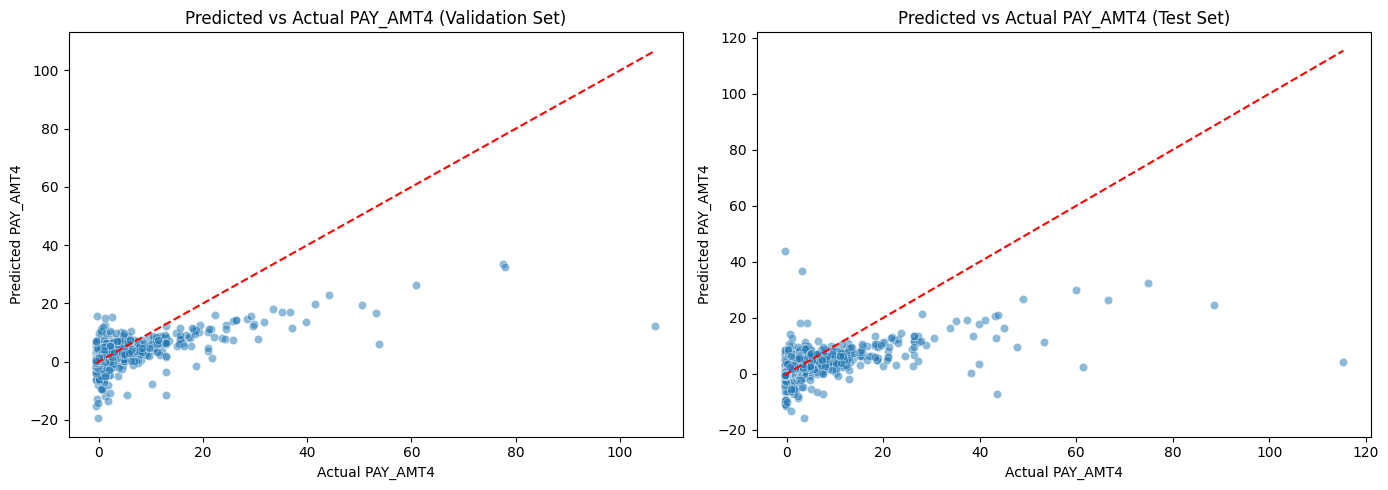

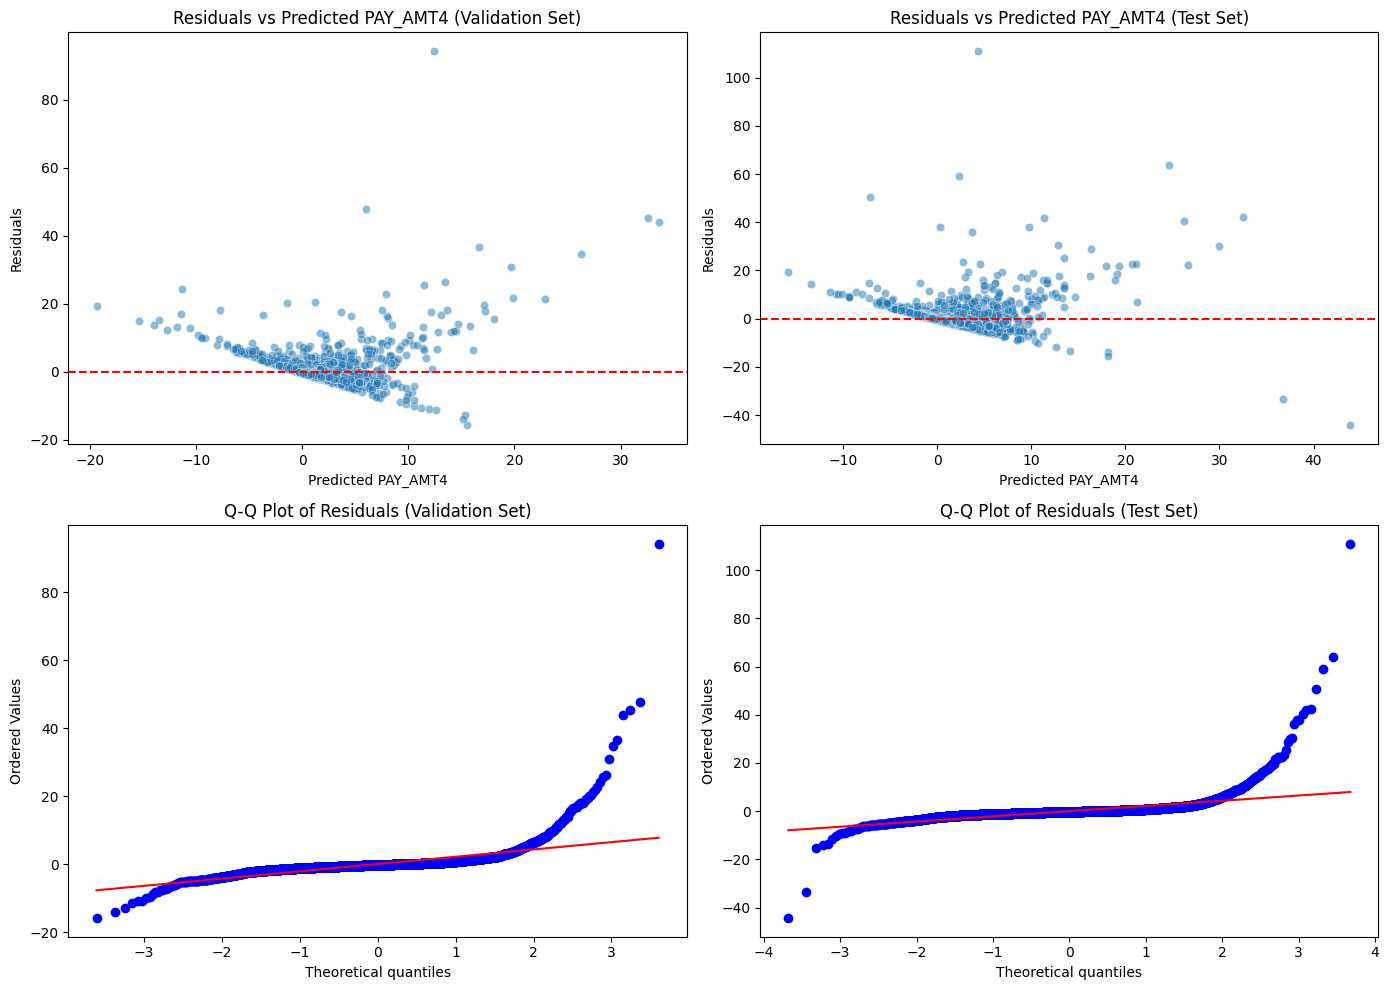

In [40]:
print("FINAL MODEL TRAINING & EVALUATION | Linear Regression (ElasticNet)")
print("="*80)

# Use best model
print("\nTraining final model with best hyperparameters...")
best_lr_model = ElasticNet(
    alpha=lr_best_params['alpha'],
    l1_ratio = lr_best_params['l1_ratio'],
    fit_intercept=lr_best_params['fit_intercept'],
    max_iter=lr_best_params['max_iter'],
    random_state=RANDOM_STATE
)

# Train on full training set
best_lr_model.fit(x_train_scaled, y_train_scaled)

# ========== VALIDATION SET EVALUATION ==========
print("\n### Validation Set Performance")
print("-" * 80)

y_tr_pred = best_lr_model.predict(x_train_scaled)
y_val_pred = best_lr_model.predict(x_val_scaled)

val_metrics = {
    'rmse': root_mean_squared_error(y_val_scaled, y_val_pred),
    'mae': mean_absolute_error(y_val_scaled, y_val_pred),
    'r2': r2_score(y_val_scaled, y_val_pred)
}

for metric, value in val_metrics.items():
    print(f"{metric:15s}: {value:.4f}")

# ========== TEST SET EVALUATION ==========
print("\n### Test Set Performance")
print("-" * 80)

y_test_pred = best_lr_model.predict(x_test_scaled)

test_metrics = {
    'rmse': root_mean_squared_error(y_test_scaled, y_test_pred),
    'mae': mean_absolute_error(y_test_scaled, y_test_pred),
    'r2': r2_score(y_test_scaled, y_test_pred)
}

for metric, value in test_metrics.items():
    print(f"{metric:15s}: {value:.4f}")

# =========== Predicted vs Actual Plot ===========
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=y_val_scaled.flatten(), y=y_val_pred, alpha=0.5, ax=axes[0])
axes[0].plot(
    [y_val_scaled.min(), y_val_scaled.max()],
    [y_val_scaled.min(), y_val_scaled.max()],
    'r--'
)
axes[0].set_xlabel('Actual PAY_AMT4')
axes[0].set_ylabel('Predicted PAY_AMT4')
axes[0].set_title('Predicted vs Actual PAY_AMT4 (Validation Set)')

sns.scatterplot(x=y_test_scaled.flatten(), y=y_test_pred, alpha=0.5, ax=axes[1])
axes[1].plot(
    [y_test_scaled.min(), y_test_scaled.max()],
    [y_test_scaled.min(), y_test_scaled.max()],
    'r--'
)
axes[1].set_xlabel('Actual PAY_AMT4')
axes[1].set_ylabel('Predicted PAY_AMT4')
axes[1].set_title('Predicted vs Actual PAY_AMT4 (Test Set)')

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'lr_predicted_vs_actual.png'), dpi=300, bbox_inches='tight')
plt.show()

# ========= Residuals Plot ==========
residuals_val = y_val_scaled.flatten() - y_val_pred
residuals_test = y_test_scaled.flatten() - y_test_pred

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Residuals vs Predicted for Validation
sns.scatterplot(x=y_val_pred.flatten(), y=residuals_val, alpha=0.5, ax=axes[0, 0])
axes[0, 0].axhline(0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Predicted PAY_AMT4')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Predicted PAY_AMT4 (Validation Set)')

# Residuals vs Predicted for Test
sns.scatterplot(x=y_test_pred, y=residuals_test, alpha=0.5, ax=axes[0, 1])
axes[0, 1].axhline(0, color='r', linestyle='--')
axes[0, 1].set_xlabel('Predicted PAY_AMT4')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residuals vs Predicted PAY_AMT4 (Test Set)')

# Q-Q plot for Validation residuals
stats.probplot(residuals_val, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot of Residuals (Validation Set)')

# Q-Q plot for Test residuals
stats.probplot(residuals_test, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot of Residuals (Test Set)')

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'lr_residuals_and_qq.png'), dpi=300, bbox_inches='tight')
plt.show()



### Feature Importance (Linear Regression Coefficients)
--------------------------------------------------------------------------------
Features retained:   34
Features eliminated: 6

Top 15 Most Important Features:
         feature  coefficient  abs_coefficient
   has_any_delay     5.713521         5.713521
       BILL_AMT5     3.814340         3.814340
n_months_delayed    -3.376999         3.376999
       BILL_AMT6    -3.094632         3.094632
 remaining_bal_5     2.634065         2.634065
 remaining_bal_6    -2.607299         2.607299
          util_4     1.574518         1.574518
          Female    -1.413293         1.413293
          util_5    -1.391103         1.391103
             SEX     1.346483         1.346483
           PAY_6     0.936775         0.936775
 MARRIAGE_Others     0.743211         0.743211
           PAY_5    -0.585539         0.585539
      bill_trend    -0.565021         0.565021
        PAY_AMT5     0.469763         0.469763


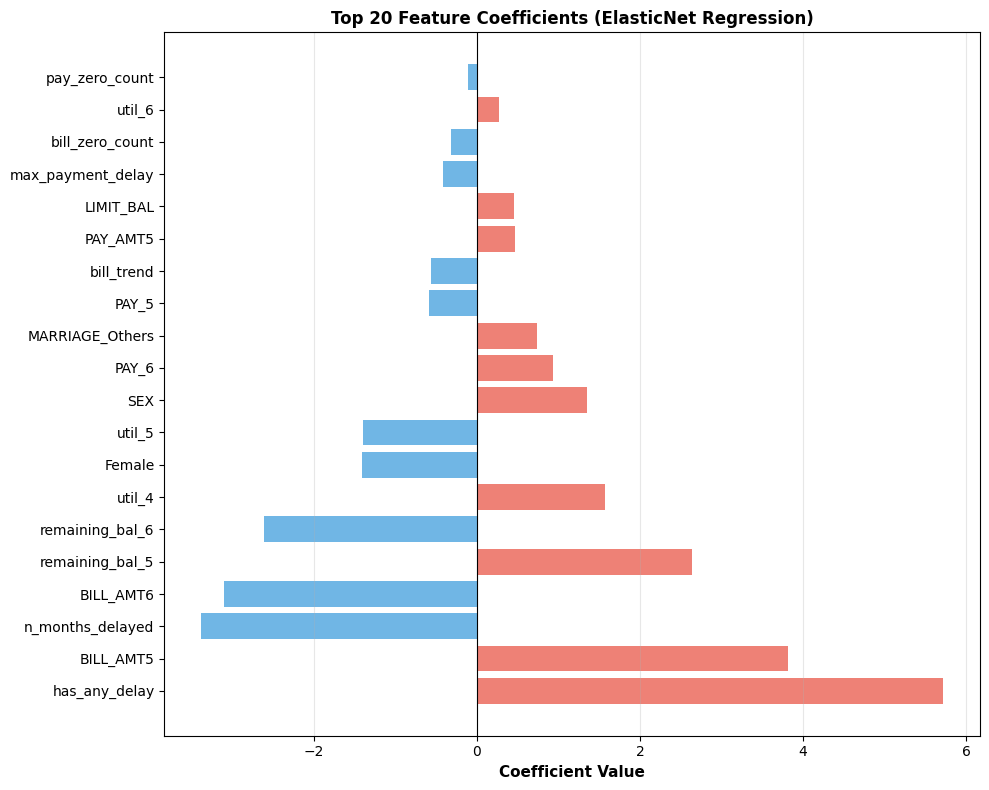


### Saving Model and Artifacts
--------------------------------------------------------------------------------


In [41]:
print("\n### Feature Importance (Linear Regression Coefficients)")
print("-" * 80)

features = x_train_scaled.columns.tolist()

coefficients = pd.DataFrame({
    'feature': features,
    'coefficient': best_lr_model.coef_,
    'abs_coefficient': np.abs(best_lr_model.coef_)
}).sort_values('abs_coefficient', ascending=False)

retained  = coefficients[coefficients['coefficient'] != 0]
eliminated = coefficients[coefficients['coefficient'] == 0]

print(f"Features retained:   {len(retained)}")
print(f"Features eliminated: {len(eliminated)}")

print("\nTop 15 Most Important Features:")
print(coefficients.head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 8))
top_coefs = coefficients.head(20)
colors = ['#e74c3c' if x > 0 else '#3498db' for x in top_coefs['coefficient']]
ax.barh(range(len(top_coefs)), top_coefs['coefficient'].values, color=colors, alpha=0.7)
ax.set_yticks(range(len(top_coefs)))
ax.set_yticklabels(top_coefs['feature'].values, fontsize=10)
ax.set_xlabel('Coefficient Value', fontsize=11, fontweight='bold')
ax.set_title('Top 20 Feature Coefficients (ElasticNet Regression)', fontsize=12, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'elasticnet_feature_coefficients.png'), dpi=300, bbox_inches='tight')
plt.show()

print("\n### Saving Model and Artifacts")
print("-" * 80)

joblib.dump(best_lr_model, os.path.join(MODELS_DIR, 'elasticnet_model.pkl'))

with open(os.path.join(MODELS_DIR, 'elasticnet_retained_features.pkl'), 'wb') as f:
    pickle.dump(retained['feature'].tolist(), f)

results_summary = {
    'timestamp': pd.Timestamp.now().isoformat(),
    'model_type': 'ElasticNet',
    'hyperparameters': lr_best_params,
    'retained_features': retained['feature'].tolist(),
    'n_features_selected': len(retained),
    'n_features_original': x_train_scaled.shape[1],
    'val_metrics': val_metrics,
    'test_metrics': test_metrics,
    'feature_importance': coefficients.to_dict(orient='list')
}

with open(os.path.join(MODELS_DIR, 'elasticnet_results_summary.pkl'), 'wb') as f:
    pickle.dump(results_summary, f)

In [42]:
print("FINAL MODEL TRAINING & EVALUATION | MLP")
print("="*80)

# Use best model
print("\nTraining final model with best hyperparameters...")
best_mlp_model = mlp_model(
    input_dim=x_train_scaled.shape[1],
    params=mlp_study.best_params
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train on full training set
history = best_mlp_model.fit(x_train_scaled, y_train_scaled,
                             validation_data=(x_val_scaled, y_val_scaled), epochs = 100,
                          batch_size=mlp_study.best_params['batch_size'],
                             callbacks=[early_stopping], verbose = 1)

best_mlp_model.summary()

FINAL MODEL TRAINING & EVALUATION | MLP

Training final model with best hyperparameters...
Epoch 1/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 19.2040 - mean_absolute_error: 1.3690 - r2_score: -0.0765 - root_mean_squared_error: 4.3811 - val_loss: 12.9489 - val_mean_absolute_error: 1.0413 - val_r2_score: 0.2426 - val_root_mean_squared_error: 3.5970
Epoch 2/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 12.8395 - mean_absolute_error: 1.1663 - r2_score: 0.2805 - root_mean_squared_error: 3.5817 - val_loss: 9.3519 - val_mean_absolute_error: 0.9501 - val_r2_score: 0.4532 - val_root_mean_squared_error: 3.0562
Epoch 3/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 10.8551 - mean_absolute_error: 1.0837 - r2_score: 0.3919 - root_mean_squared_error: 3.2928 - val_loss: 12.7458 - val_mean_absolute_error: 0.9050 - val_r2_score: 0.2546 - val_root_mean_squared_error: 3.5682
Epoch 4/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 8.3022 - mean_absolute_error: 0.9807 - r2_scor

Model: "sequential_41"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_147 (Dense)               │ (None, 32)             │         1,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_106 (Dropout)           │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_148 (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,037 (15.77 KB)

 Trainable params: 1,345 (5.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,692 (10.52 KB)


### Training History - Final Metrics
loss                          : 4.563520
val_loss                      : 4.622103
root_mean_squared_error       : 2.122663
val_root_mean_squared_error   : 2.136378
mean_absolute_error           : 0.675219
val_mean_absolute_error       : 0.550766
r2_score                      : 0.747306
val_r2_score                  : 0.732807


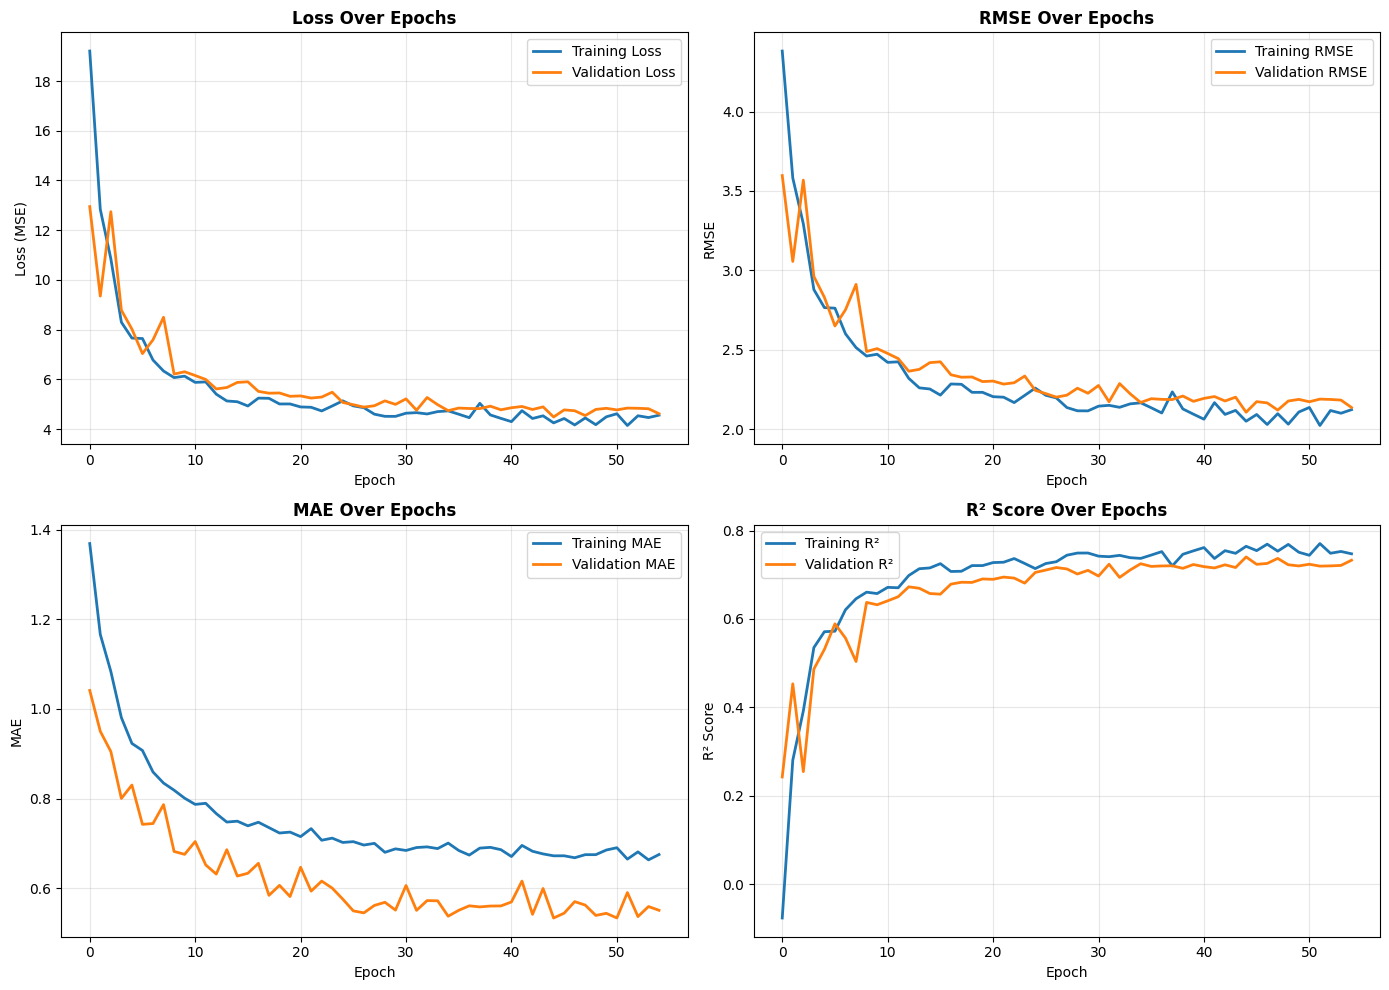

In [43]:
# ========== ACCESS TRAINING HISTORY METRICS ==========
print("\n### Training History - Final Metrics")
print("=" * 80)

# Extract final epoch metrics
final_metrics = {
    'loss': history.history['loss'][-1],
    'val_loss': history.history['val_loss'][-1],
    'root_mean_squared_error': history.history['root_mean_squared_error'][-1],
    'val_root_mean_squared_error': history.history['val_root_mean_squared_error'][-1],
    'mean_absolute_error': history.history['mean_absolute_error'][-1],
    'val_mean_absolute_error': history.history['val_mean_absolute_error'][-1],
    'r2_score': history.history['r2_score'][-1],
    'val_r2_score': history.history['val_r2_score'][-1],
}

for metric, value in final_metrics.items():
    print(f"{metric:30s}: {value:.6f}")

# ========== PLOT TRAINING HISTORY ==========
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss
axes[0, 0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0, 0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0, 0].set_title('Loss Over Epochs', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss (MSE)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# RMSE
axes[0, 1].plot(history.history['root_mean_squared_error'], label='Training RMSE', linewidth=2)
axes[0, 1].plot(history.history['val_root_mean_squared_error'], label='Validation RMSE', linewidth=2)
axes[0, 1].set_title('RMSE Over Epochs', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('RMSE')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# MAE
axes[1, 0].plot(history.history['mean_absolute_error'], label='Training MAE', linewidth=2)
axes[1, 0].plot(history.history['val_mean_absolute_error'], label='Validation MAE', linewidth=2)
axes[1, 0].set_title('MAE Over Epochs', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('MAE')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# R² Score
axes[1, 1].plot(history.history['r2_score'], label='Training R²', linewidth=2)
axes[1, 1].plot(history.history['val_r2_score'], label='Validation R²', linewidth=2)
axes[1, 1].set_title('R² Score Over Epochs', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('R² Score')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'mlp_training_history.png'), dpi=300, bbox_inches='tight')
plt.show()


### Validation Set Performance
--------------------------------------------------------------------------------
rmse           : 2.1067
mae            : 0.5336
r2             : 0.7402

### Test Set Performance
--------------------------------------------------------------------------------
rmse           : 2.6112
mae            : 0.5720
r2             : 0.6172


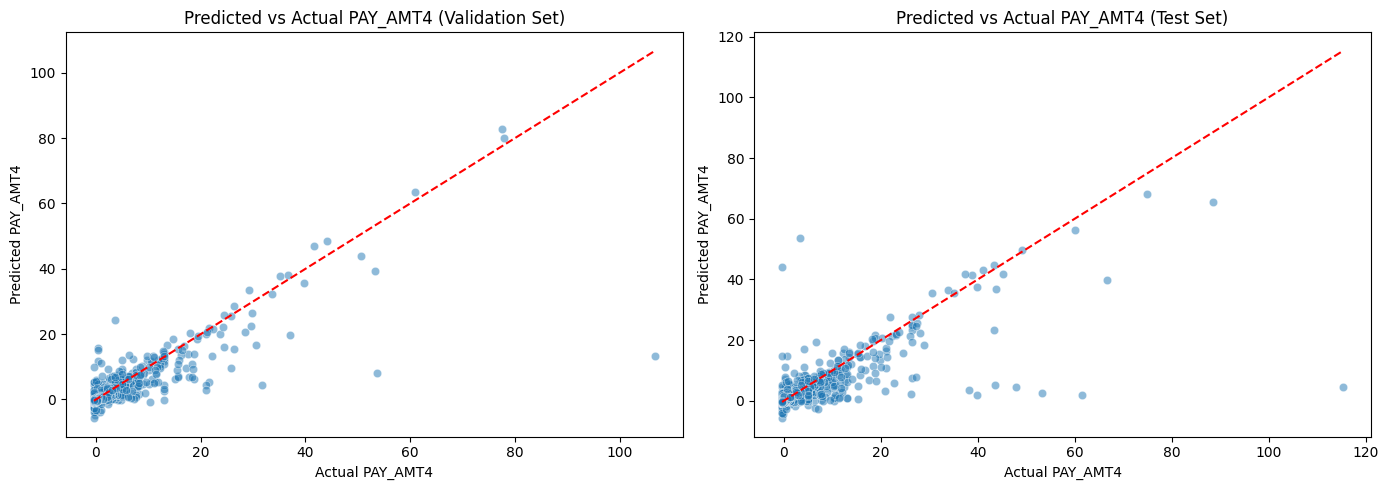

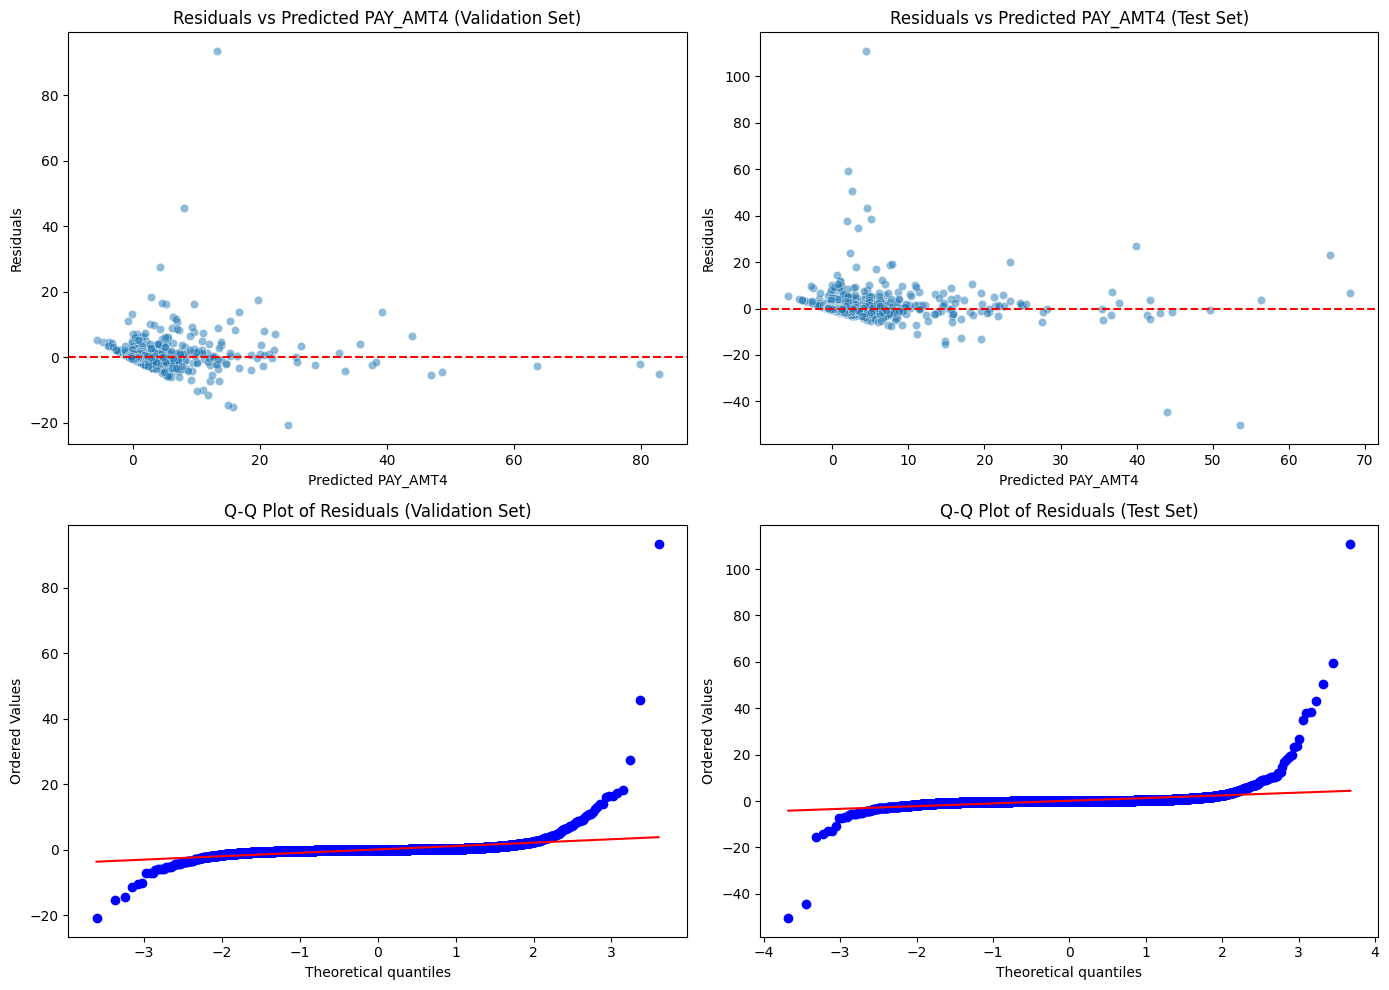

In [45]:
# ========== VALIDATION SET EVALUATION ==========
print("\n### Validation Set Performance")
print("-" * 80)

y_tr_pred = best_mlp_model.predict(x_train_scaled, verbose=0)
y_val_pred = best_mlp_model.predict(x_val_scaled, verbose=0)

val_metrics = {
    'rmse': root_mean_squared_error(y_val_scaled, y_val_pred),
    'mae': mean_absolute_error(y_val_scaled, y_val_pred),
    'r2': r2_score(y_val_scaled, y_val_pred)
}

for metric, value in val_metrics.items():
    print(f"{metric:15s}: {value:.4f}")

# ========== TEST SET EVALUATION ==========
print("\n### Test Set Performance")
print("-" * 80)

y_test_pred = best_mlp_model.predict(x_test_scaled, verbose=0)

test_metrics = {
    'rmse': root_mean_squared_error(y_test_scaled, y_test_pred),
    'mae': mean_absolute_error(y_test_scaled, y_test_pred),
    'r2': r2_score(y_test_scaled, y_test_pred)
}

for metric, value in test_metrics.items():
    print(f"{metric:15s}: {value:.4f}")

# =========== Predicted vs Actual Plot ===========
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=y_val_scaled.flatten(), y=y_val_pred.flatten(), alpha=0.5, ax=axes[0])
axes[0].plot(
    [y_val_scaled.min(), y_val_scaled.max()],
    [y_val_scaled.min(), y_val_scaled.max()],
    'r--'
)
axes[0].set_xlabel('Actual PAY_AMT4')
axes[0].set_ylabel('Predicted PAY_AMT4')
axes[0].set_title('Predicted vs Actual PAY_AMT4 (Validation Set)')

sns.scatterplot(x=y_test_scaled.flatten(), y=y_test_pred.flatten(), alpha=0.5, ax=axes[1])
axes[1].plot(
    [y_test_scaled.min(), y_test_scaled.max()],
    [y_test_scaled.min(), y_test_scaled.max()],
    'r--'
)
axes[1].set_xlabel('Actual PAY_AMT4')
axes[1].set_ylabel('Predicted PAY_AMT4')
axes[1].set_title('Predicted vs Actual PAY_AMT4 (Test Set)')

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'mlp_predicted_vs_actual.png'), dpi=300, bbox_inches='tight')
plt.show()

# ========= Residuals Plot ==========
residuals_val = y_val_scaled.flatten() - y_val_pred.flatten()
residuals_test = y_test_scaled.flatten() - y_test_pred.flatten()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Residuals vs Predicted for Validation
sns.scatterplot(x=y_val_pred.flatten(), y=residuals_val, alpha=0.5, ax=axes[0, 0])
axes[0, 0].axhline(0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Predicted PAY_AMT4')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Predicted PAY_AMT4 (Validation Set)')

# Residuals vs Predicted for Test
sns.scatterplot(x=y_test_pred.flatten(), y=residuals_test, alpha=0.5, ax=axes[0, 1])
axes[0, 1].axhline(0, color='r', linestyle='--')
axes[0, 1].set_xlabel('Predicted PAY_AMT4')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residuals vs Predicted PAY_AMT4 (Test Set)')

# Q-Q plot for Validation residuals
stats.probplot(residuals_val, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot of Residuals (Validation Set)')

# Q-Q plot for Test residuals
stats.probplot(residuals_test, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot of Residuals (Test Set)')

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'mlp_residuals_and_qq.png'), dpi=300, bbox_inches='tight')
plt.show()


### Feature Importance & Interpretability (MLP)
--------------------------------------------------------------------------------


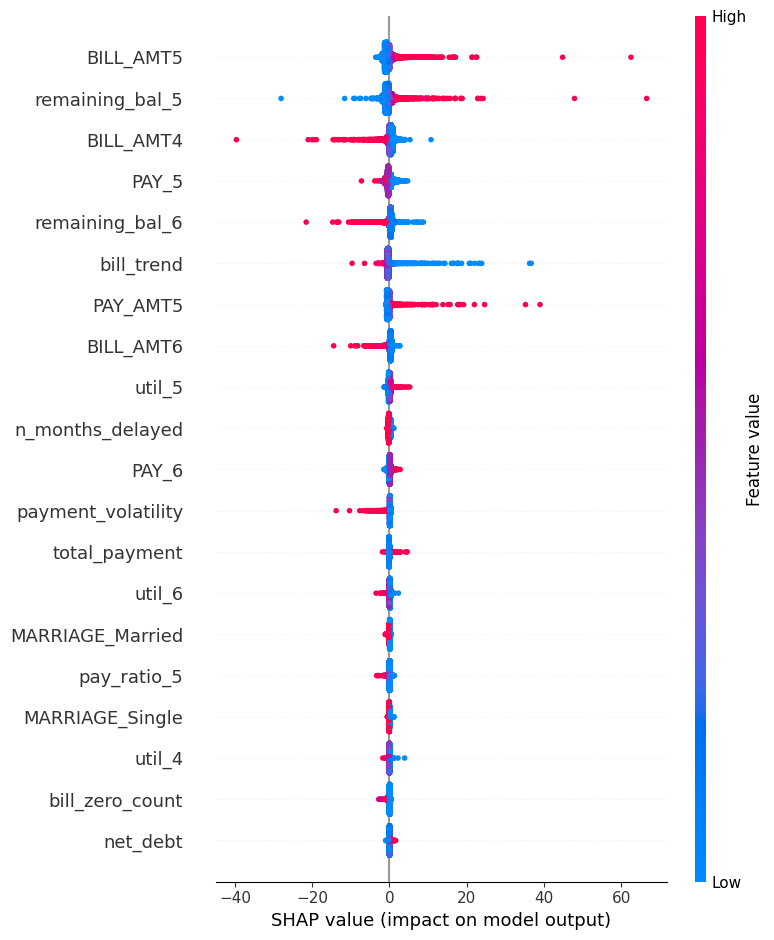

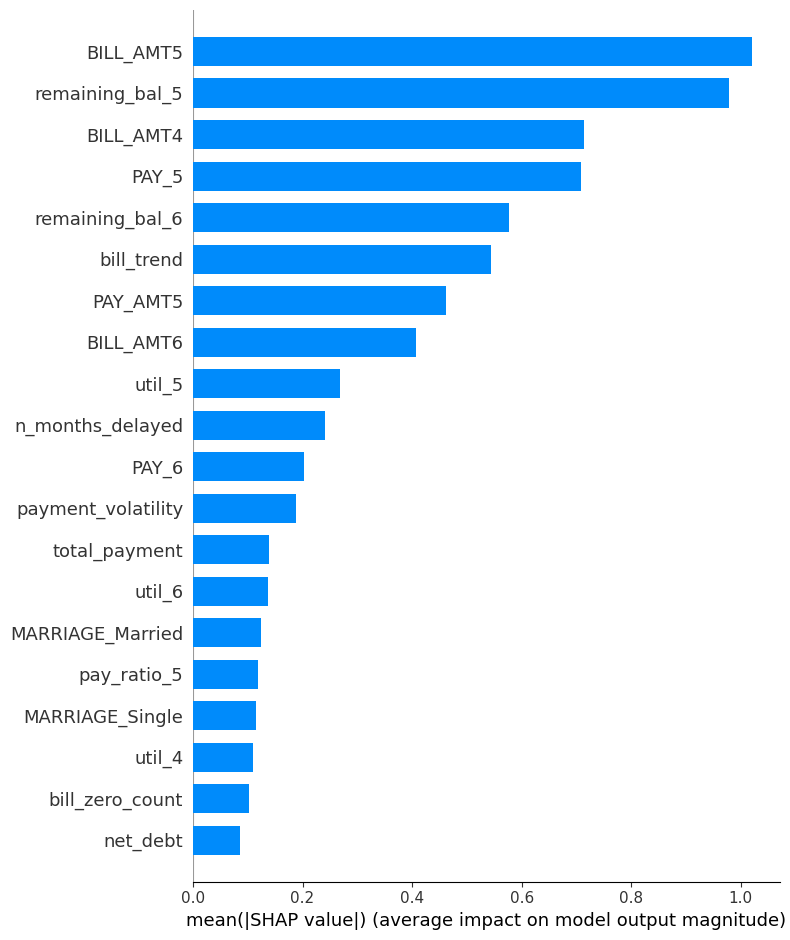


### Saving Model and Artifacts
--------------------------------------------------------------------------------


In [46]:
print("\n### Feature Importance & Interpretability (MLP)")
print("-" * 80)

selected_features = x_train_scaled.columns.tolist()
background = x_train_scaled.sample(n=min(100, len(x_train_scaled)), random_state=RANDOM_STATE)

# Convert background and x_test_scaled to numpy arrays for DeepExplainer
explainer = shap.DeepExplainer(best_mlp_model, background.values)
shap_values = explainer.shap_values(x_test_scaled.values, check_additivity=False)

# shap_values for Keras models often returns a list of arrays, even for single output.
# Access the first element of the list for the actual SHAP values.
# Pass x_test_scaled.values for consistency with the explainer's input.
shap.summary_plot(shap_values.squeeze(), x_test_scaled.values, feature_names=selected_features)
shap.summary_plot(shap_values.squeeze(), x_test_scaled.values, feature_names=selected_features,
                  plot_type='bar')

print("\n### Saving Model and Artifacts")
print("-" * 80)

joblib.dump(best_mlp_model, os.path.join(MODELS_DIR, 'mlp_model.pkl'))

# Ensure shap_values[0] is used for creating the DataFrame
shap_df = pd.DataFrame(shap_values.squeeze(), columns=selected_features)
feature_importance = shap_df.abs().mean().sort_values(ascending=False)

results_summary = {
    'timestamp': pd.Timestamp.now().isoformat(),
    'model_type': 'MLP+DropOut',
    'hyperparameters': mlp_study.best_params,
    'selected_features': selected_features,
    'n_features': len(selected_features),
    'n_features_original': x_train_scaled.shape[1],
    'val_metrics': val_metrics,
    'test_metrics': test_metrics,
    'feature_importance': feature_importance.to_dict()
}

with open(os.path.join(MODELS_DIR, 'MLP_results_summary.pkl'), 'wb') as f:
    pickle.dump(results_summary, f)


## Model Comparison Summary

In [47]:
# Function to compute all required metrics
def compute_metrics(y_true, y_pred):
    rmse = root_mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

# Compute metrics for Logistic Regression
# Train
y_train_pred_lr = best_lr_model.predict(x_train_scaled)
train_rmse_lr, train_mae_lr, train_r2_lr = compute_metrics(y_train_scaled, y_train_pred_lr)

# Validation
y_val_pred_lr = best_lr_model.predict(x_val_scaled)
val_rmse_lr, val_mae_lr, val_r2_lr = compute_metrics(y_val_scaled, y_val_pred_lr)

# Test
y_test_pred_lr = best_lr_model.predict(x_test_scaled)
test_rmse_lr, test_mae_lr, test_r2_lr = compute_metrics(y_test_scaled, y_test_pred_lr)

# Compute metrics for MLP (using existing predictions) - possible fix for future
# Train
train_rmse_mlp, train_mae_mlp, train_r2_mlp = compute_metrics(y_train_scaled, y_tr_pred)

# Validation
val_rmse_mlp, val_mae_mlp, val_r2_mlp = compute_metrics(y_val_scaled, y_val_pred)

# Test
test_rmse_mlp, test_mae_mlp, test_r2_mlp = compute_metrics(y_test_scaled, y_test_pred)

# Create DataFrame
comparison_df = pd.DataFrame({
    'Model': ['Elastic Net Regression'] * 3 + ['MLP + DropOut'] * 3,
    'Dataset': ['Train', 'Validation', 'Test'] * 2,
    'RMSE': [train_rmse_lr, val_rmse_lr, test_rmse_lr, train_rmse_mlp, val_rmse_mlp, test_rmse_mlp],
    'MAE': [train_mae_lr, val_mae_lr, test_mae_lr, train_mae_mlp, val_mae_mlp, test_mae_mlp],
    'R2': [train_r2_lr, val_r2_lr, test_r2_lr, train_r2_mlp, val_r2_mlp, test_r2_mlp]
})
# Set double level index for Model and Dataset
comparison_df.set_index(['Model', 'Dataset'], inplace=True)
# Print the DataFrame
comparison_df

RMSE       MAE        R2
Model                  Dataset                                 
Elastic Net Regression Train       3.270163  1.293704  0.400247
                       Validation  3.159969  1.288751  0.415433
                       Test        3.386327  1.277490  0.356237
MLP + DropOut          Train       1.903303  0.528788  0.796835
                       Validation  2.106699  0.533574  0.740179
                       Test        2.611193  0.571992  0.617223

In [48]:
# Best model by metric in test set
test_comparison = comparison_df.xs('Test', level='Dataset')

print(f"Columns in test_comparison: {test_comparison.columns.tolist()}")

for metric in test_comparison.columns:
    if metric in ['RMSE', 'MAE']:
        best_model = test_comparison[metric].idxmin()  # Use idxmin for metrics where lower is better
    else:  # Assuming R2, where higher is better
        best_model = test_comparison[metric].idxmax()
    best_value = test_comparison.loc[best_model, metric]
    print(f"Best {metric}: {best_model} with value {best_value:.4f}")

Columns in test_comparison: ['RMSE', 'MAE', 'R2']
Best RMSE: MLP + DropOut with value 2.6112
Best MAE: MLP + DropOut with value 0.5720
Best R2: MLP + DropOut with value 0.6172
